# Experiment Claims

**Source file:** `iid_experiment_markov.pkl`

---

## Claim 4 (Markov): An IID transformer exploits Markov structure it was never trained on.

The IID-trained model is applied unchanged to a p_stay sweep alongside Laplace and CTW (depth=8). The transformer wins at high p_stay without any specialized training. Causal attention reads autocorrelation within the test sequence and adapts on the fly. CTW also exploits memory but requires more context to build up its tree. At short sequences the transformer's in-context learning gives it an edge over both Laplace and CTW.

The mechanism breaks down when p_stay is near 0.5. At that point the chain is near-IID and there is no autocorrelation to exploit.

*Key numbers:* p_stay=0.99, l=10: transformer 0.384, Laplace 0.401. p_stay=0.5, l=10: transformer loses to Laplace.


In [118]:
import sys
sys.path.append('../../')
from ctw.ctw import CTW
import numpy as np
import torch
import torch.nn.functional as F
from mingpt.model import GPT
import pickle


In [119]:
experiment_save_folder = './experiments/'
N_values = [10, 25, 50, 100, 200, 300, 499]

In [120]:

def iid_generate(p_dict, N):
    p0 = p_dict[0]
    p1 = p_dict[1]
    return np.random.choice([0,1], size=N, p=[p0, p1])

def generate_bin_pmf():
    p = np.random.rand()
    dict_out = {
        0: p,
        1: 1-p
    }
    return dict_out

def convert_sample_to_pmf(sample):
    values, counts = np.unique(sample, return_counts=True)
    probs = counts/counts.sum()
    return dict(zip(values, probs))

def entropy_calc(pmf):
    pmf = clean_pmf(pmf)
    pmf_array = np.asarray(list(pmf.values()))
    return -np.sum(pmf_array * np.log2(pmf_array))

def clean_pmf(pmf):
    return {k: v for k, v in pmf.items() if v > 0.0}

In [121]:
def sequential_universal_source_coding(seq, p_array = None):
    total_bits = 0
    k = 0
    i = 0

    for bit in seq:
        if p_array is not None:
            p1 = p_array[i]
        else:
            p1 = (k+1) / (i+2)
        p0 = 1-p1

        if bit == 1:
            total_bits += -np.log2(p1)
        else:
            total_bits += -np.log2(p0)
        k += bit
        i += 1

    bits_per_symbol = total_bits / len(seq)
    return bits_per_symbol

def ctw_p_array(sequence, depth=8):
    sequence = [int(x) for x in sequence]
    ctw = CTW(depth=depth, symbols=2)
    distributions = ctw.predict_sequence(sequence)
    # predict_sequence returns distributions[:,n] AFTER updating on seq[depth+n].
    # So distributions[1, n] predicts seq[depth+n+1], not seq[depth+n].
    # Correct causal alignment: pad depth+1 flat priors, then use p_ones[:-1].
    p_ones = distributions[1, :].tolist()
    p_array = [0.5] * (depth + 1) + p_ones[:-1]
    return p_array


In [122]:

# generate an array of probabilities given a bit sequence

def transformer_p_array(sequence, model, device='mps'):
    model.eval()
    sequence=torch.tensor(sequence, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        logits, _ = model(sequence)  # [1, T, vocab_size]
        # convert to probabilities
        probs = F.softmax(logits, dim=-1)  # [1, T, vocab_size]
        # extract probability of token=1 at each timestep
        p_array = [0.5] + probs[0, :-1, 1].tolist()
    
    return p_array

In [123]:
def load_model(model_dir):
    checkpoint = torch.load(model_dir, map_location='cpu')
    block_size = checkpoint['block_size']
    
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = block_size
    
    model = GPT(model_config)
    model.load_state_dict(checkpoint['state_dict'])
    model = model.to('mps')
    model.eval()
    return model

In [124]:
def markov_generate(p_stay, N):
    state = np.random.choice([0, 1])  # stationary is uniform for symmetric chain
    seq = [state]
    for _ in range(N - 1):
        if np.random.rand() < p_stay:
            seq.append(state)  # stay
        else:
            state = 1 - state  # switch
            seq.append(state)
    return np.array(seq)


In [125]:
def run_markov_experiment(model, p_stay_values, N_values, output_file, n_trials=100, device='mps', ctw_depth=8):
    all_results = {}
    save_dir = experiment_save_folder + output_file
    print(f'Saving to {save_dir}')

    for p_stay in p_stay_values:
        print(f"\nRunning p_stay={p_stay}")
        all_results[p_stay] = {}

        for N in N_values:
            laplace_bps_trials = []
            transformer_bps_trials = []
            ctw_bps_trials = []

            for trial in range(n_trials):
                seq = markov_generate(p_stay, N)
                laplace_bps_trials.append(sequential_universal_source_coding(seq))
                p_array = transformer_p_array(seq, model, device=device)
                transformer_bps_trials.append(sequential_universal_source_coding(seq, p_array=p_array))
                p_array_ctw = ctw_p_array(seq, depth=ctw_depth)
                ctw_bps_trials.append(sequential_universal_source_coding(seq, p_array=p_array_ctw))

            all_results[p_stay][N] = {
                'laplace':     (np.mean(laplace_bps_trials), np.std(laplace_bps_trials)),
                'transformer': (np.mean(transformer_bps_trials), np.std(transformer_bps_trials)),
                'ctw':         (np.mean(ctw_bps_trials), np.std(ctw_bps_trials)),
            }
            print(f"  N={N}: laplace={np.mean(laplace_bps_trials):.4f}, transformer={np.mean(transformer_bps_trials):.4f}, ctw={np.mean(ctw_bps_trials):.4f}")

    with open(save_dir, 'wb') as f:
        pickle.dump(all_results, f)
    print(f'Saved experiment to {save_dir}')


In [126]:
import os

SAVE_PATH = experiment_save_folder + 'iid_experiment_markov.pkl'

p_stay_sweep = [0.0, 0.3, 0.5, 0.7, 0.9, 0.99]
N_values = [10, 25, 50, 100, 200, 300, 499]

if os.path.exists(SAVE_PATH):
    print(f'Checkpoint found, loading iid_experiment_markov.pkl')
else:
    model_iid = load_model('../IID/models/iid_model.pt')
    run_markov_experiment(model_iid, p_stay_sweep, N_values,
                          output_file='iid_experiment_markov.pkl', n_trials=100, device='mps')


number of parameters: 0.11M
Saving to ./experiments/iid_experiment_markov.pkl

Running p_stay=0.0
  N=10: laplace=1.1437, transformer=1.1566, ctw=1.0000
  N=25: laplace=1.0804, transformer=1.0764, ctw=2.1289
  N=50: laplace=1.0504, transformer=1.0476, ctw=3.4834
  N=100: laplace=1.0301, transformer=1.0327, ctw=4.7572
  N=200: laplace=1.0175, transformer=1.0256, ctw=5.9380
  N=300: laplace=1.0126, transformer=1.0236, ctw=6.5948
  N=499: laplace=1.0083, transformer=1.0227, ctw=7.3933

Running p_stay=0.3
  N=10: laplace=1.1084, transformer=1.1224, ctw=1.0000
  N=25: laplace=1.0690, transformer=1.0696, ctw=1.0969
  N=50: laplace=1.0452, transformer=1.0460, ctw=1.1606
  N=100: laplace=1.0270, transformer=1.0286, ctw=1.1851
  N=200: laplace=1.0162, transformer=1.0199, ctw=1.2069
  N=300: laplace=1.0116, transformer=1.0162, ctw=1.1982
  N=499: laplace=1.0077, transformer=1.0136, ctw=1.2051

Running p_stay=0.5
  N=10: laplace=1.0622, transformer=1.0738, ctw=1.0000
  N=25: laplace=1.0465, trans

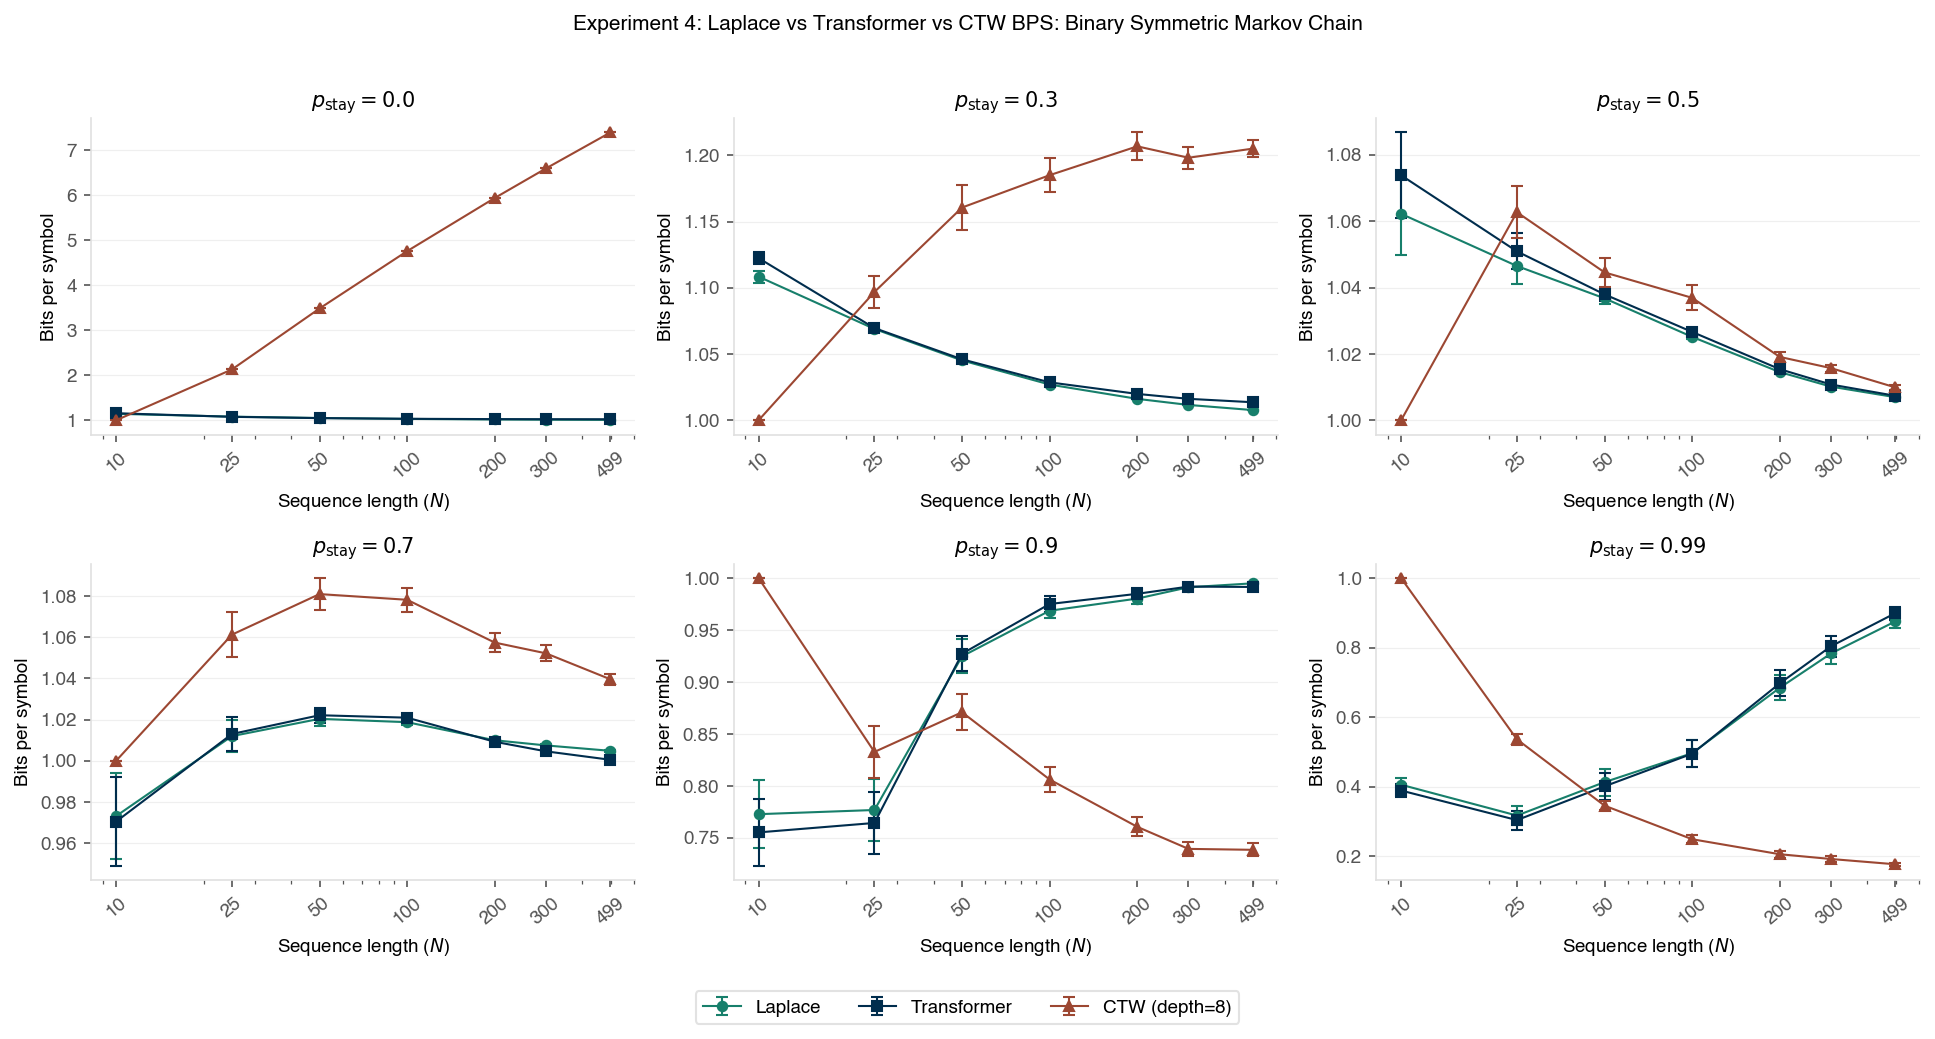

Saved figures/markov_bps_grid


In [127]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pickle
import os
os.makedirs('figures', exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────
C_TRANSFORMER = '#002d4d'
C_LAPLACE     = '#177F6B'
C_CTW         = '#9C4732'
C_ENTROPY     = '#888888'
BG            = '#FFFFFF'
GRID          = '#E0E0E0'

matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRID,
    'axes.linewidth':    0.8,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.titleweight':  'bold',
    'legend.fontsize':   9,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  GRID,
    'lines.linewidth':   1.0,
    'lines.markersize':  4.5,
})

def style_ax(ax):
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def set_log_xticks(ax, N_values):
    ax.set_xscale('log')
    ax.set_xticks(N_values)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)

p_stay_sweep = [0.0, 0.3, 0.5, 0.7, 0.9, 0.99]
N_values = [10, 25, 50, 100, 200, 300, 499]
n_trials = 100

with open('./experiments/iid_experiment_markov.pkl', 'rb') as f:
    all_data = pickle.load(f)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=150)
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for idx, p_stay in enumerate(p_stay_sweep):
    ax = axes[idx]
    data = all_data[p_stay]
    lap_m  = [data[N]['laplace'][0]     for N in N_values]
    tr_m   = [data[N]['transformer'][0] for N in N_values]
    ctw_m  = [data[N]['ctw'][0]         for N in N_values]
    lap_se = [data[N]['laplace'][1]     / n_trials**0.5 for N in N_values]
    tr_se  = [data[N]['transformer'][1] / n_trials**0.5 for N in N_values]
    ctw_se = [data[N]['ctw'][1]         / n_trials**0.5 for N in N_values]
    ax.errorbar(N_values, lap_m, yerr=lap_se, fmt='o-', capsize=3,
                color=C_LAPLACE, lw=1.0, ms=4.5, label='Laplace')
    ax.errorbar(N_values, tr_m,  yerr=tr_se,  fmt='s-', capsize=3,
                color=C_TRANSFORMER, lw=1.0, ms=4.5, label='Transformer')
    ax.errorbar(N_values, ctw_m, yerr=ctw_se, fmt='^-', capsize=3,
                color=C_CTW, lw=1.0, ms=4.5, label='CTW (depth=8)')
    set_log_xticks(ax, N_values)
    ax.set_title(f'$p_{{\\mathrm{{stay}}}}={p_stay}$', pad=5)
    ax.set_xlabel('Sequence length ($N$)', fontsize=9)
    ax.set_ylabel('Bits per symbol', fontsize=9)
    style_ax(ax)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove() if ax.get_legend() else None
fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=9)
fig.suptitle('Experiment 4: Laplace vs Transformer vs CTW BPS: Binary Symmetric Markov Chain',
             fontsize=10, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig('figures/markov_bps_grid.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/markov_bps_grid.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/markov_bps_grid')


In [128]:
from torch.utils.data import Dataset
from mingpt.model import GPT
from mingpt.trainer import Trainer

model_save_folder = './models/'
import os
os.makedirs(model_save_folder, exist_ok=True)

class MarkovDataset(Dataset):
    def __init__(self, p_stay, n=500, num_samples=10000):
        self.block_size = n - 1
        self.data = []
        for _ in range(num_samples):
            seq = torch.tensor(markov_generate(p_stay, n), dtype=torch.long)
            x = seq[:-1].clone()
            y = seq[1:].clone()
            self.data.append((x, y))

    def get_block_size(self):
        return self.block_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def model_configure(dataset, iters=1000, learn_rate=1e-4):
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = dataset.get_block_size()
    model = GPT(model_config)
    model = model.to('mps')
    train_config = Trainer.get_default_config()
    train_config.learning_rate = learn_rate
    train_config.max_iters = iters
    train_config.num_workers = 0
    train_config.device = 'mps'
    trainer = Trainer(train_config, model, dataset)
    return model, trainer

def train_run(model, trainer, dataset, save_name):
    trainer.run()
    checkpoint = {
        'state_dict': model.state_dict(),
        'block_size': dataset.get_block_size(),
    }
    torch.save(checkpoint, model_save_folder + save_name)
    print(f'Saved {save_name}')


In [129]:
import os, pickle

p_stay_sweep  = [0.0, 0.3, 0.5, 0.7, 0.9, 0.99]
N_values      = [10, 25, 50, 100, 200, 300, 499]
n_trials      = 100
seq_samples   = 500
num_samples   = 10000
iters         = 1000

SAVE_PATH = experiment_save_folder + 'specialized_experiment_markov.pkl'

if os.path.exists(SAVE_PATH):
    print('Checkpoint found, loading specialized_experiment_markov.pkl')
    with open(SAVE_PATH, 'rb') as f:
        specialized_results = pickle.load(f)
else:
    specialized_results = {}

    for p_stay in p_stay_sweep:
        model_path = model_save_folder + f'markov_{p_stay}_model.pt'
        print(f'\np_stay={p_stay}')

        if os.path.exists(model_path):
            print(f'  Checkpoint found, loading markov_{p_stay}_model.pt')
            model = load_model(model_path)
        else:
            dataset = MarkovDataset(p_stay=p_stay, n=seq_samples, num_samples=num_samples)
            model, trainer = model_configure(dataset, iters=iters)
            train_run(model, trainer, dataset, f'markov_{p_stay}_model.pt')

        specialized_results[p_stay] = {}
        for N in N_values:
            lap_trials, tr_trials, ctw_trials = [], [], []
            for _ in range(n_trials):
                seq = markov_generate(p_stay, N)
                lap_trials.append(sequential_universal_source_coding(seq))
                p_arr = transformer_p_array(seq, model, device='mps')
                tr_trials.append(sequential_universal_source_coding(seq, p_array=p_arr))
                p_arr_ctw = ctw_p_array(seq, depth=8)
                ctw_trials.append(sequential_universal_source_coding(seq, p_array=p_arr_ctw))
            specialized_results[p_stay][N] = {
                'laplace':     (np.mean(lap_trials),  np.std(lap_trials)),
                'transformer': (np.mean(tr_trials),   np.std(tr_trials)),
                'ctw':         (np.mean(ctw_trials),  np.std(ctw_trials)),
            }
            print(f'  N={N}: lap={np.mean(lap_trials):.4f}, tr={np.mean(tr_trials):.4f}, ctw={np.mean(ctw_trials):.4f}')

    with open(SAVE_PATH, 'wb') as f:
        pickle.dump(specialized_results, f)
    print('Saved', SAVE_PATH)


Checkpoint found, loading specialized_experiment_markov.pkl


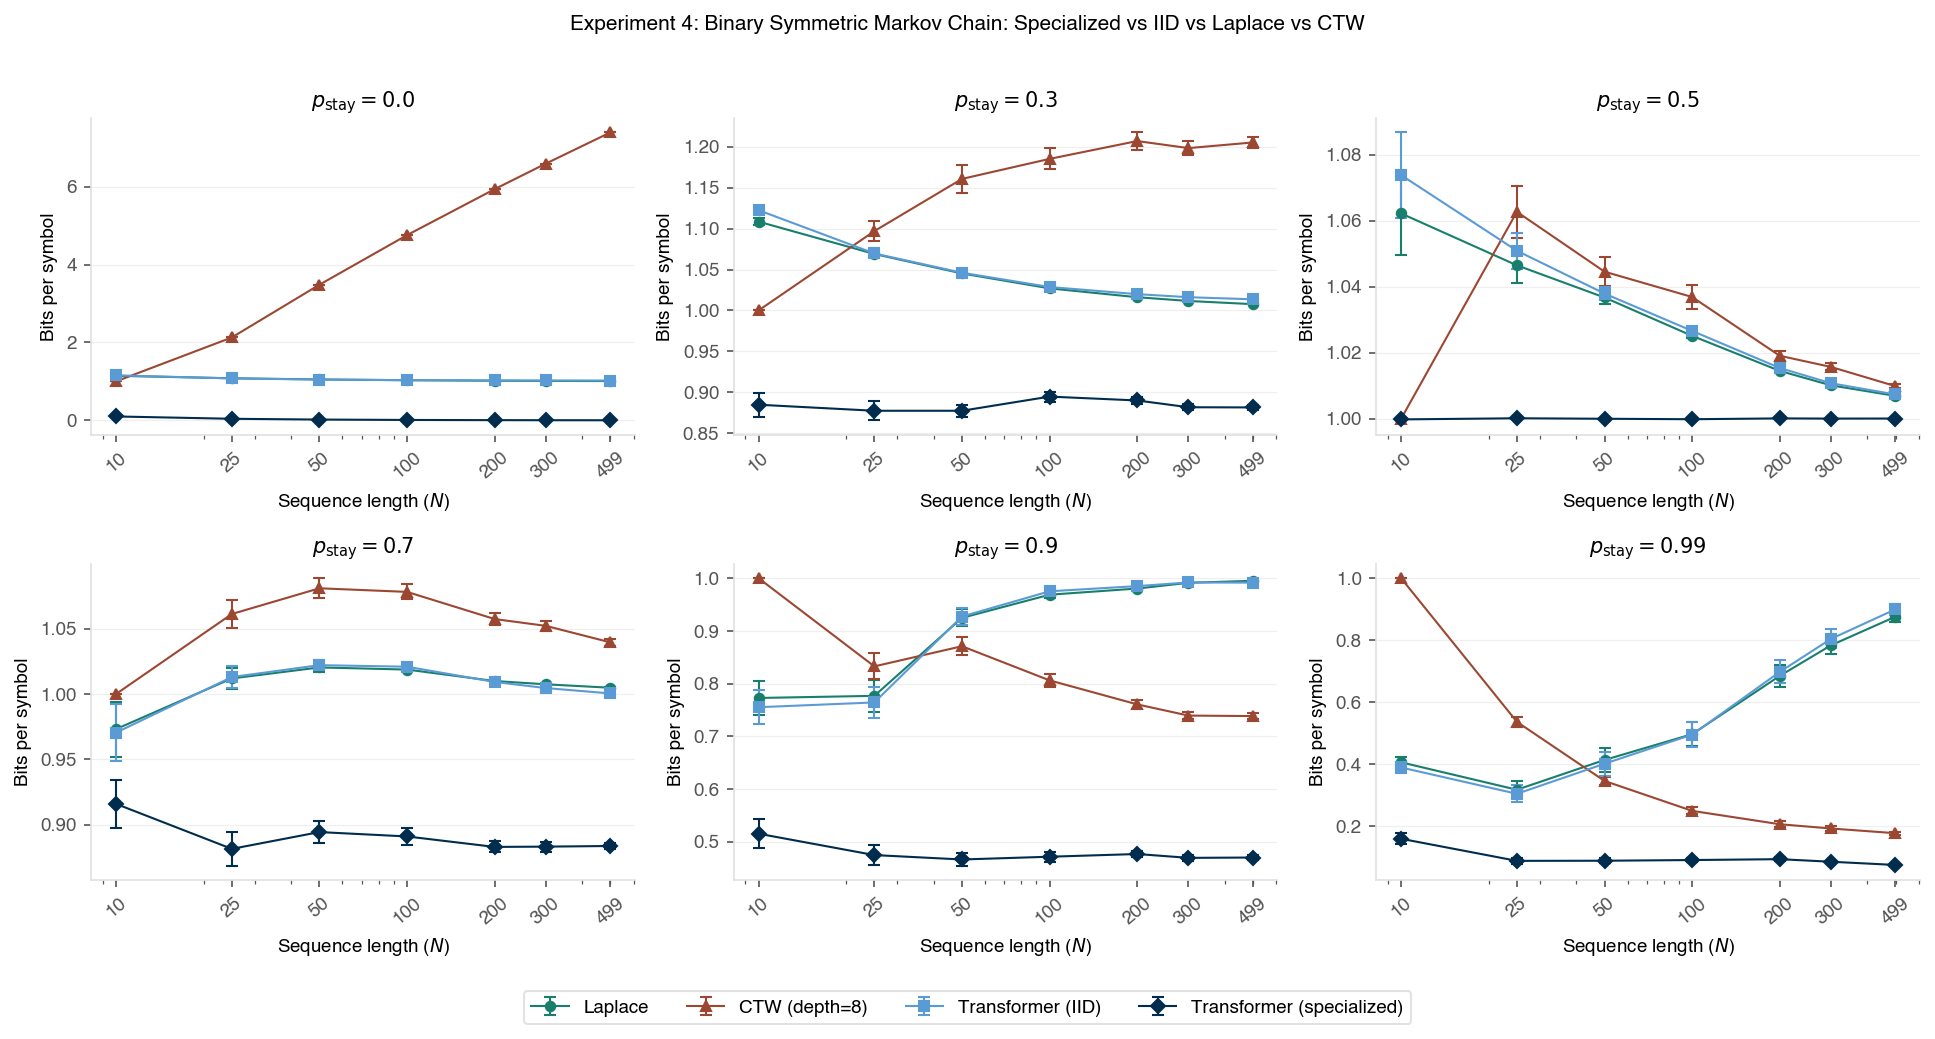

Saved figures/markov_bps_grid_comparison


In [130]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pickle
import os
os.makedirs('figures', exist_ok=True)

C_SPECIALIZED = '#002d4d'
C_IID         = '#5B9BD5'
C_LAPLACE     = '#177F6B'
C_CTW         = '#9C4732'
BG            = '#FFFFFF'
GRID          = '#E0E0E0'

matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRID,
    'axes.linewidth':    0.8,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.titleweight':  'bold',
    'legend.fontsize':   9,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  GRID,
    'lines.linewidth':   1.0,
    'lines.markersize':  4.5,
})

def style_ax(ax):
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def set_log_xticks(ax, N_values):
    ax.set_xscale('log')
    ax.set_xticks(N_values)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)

p_stay_sweep = [0.0, 0.3, 0.5, 0.7, 0.9, 0.99]
N_values     = [10, 25, 50, 100, 200, 300, 499]
n_trials     = 100

with open('./experiments/iid_experiment_markov.pkl', 'rb') as f:
    iid_data = pickle.load(f)
with open('./experiments/specialized_experiment_markov.pkl', 'rb') as f:
    spec_data = pickle.load(f)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=150)
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for idx, p_stay in enumerate(p_stay_sweep):
    ax = axes[idx]
    iid  = iid_data[p_stay]
    spec = spec_data[p_stay]

    lap_m   = [iid[N]['laplace'][0]      for N in N_values]
    iid_m   = [iid[N]['transformer'][0]  for N in N_values]
    ctw_m   = [iid[N]['ctw'][0]          for N in N_values]
    spec_m  = [spec[N]['transformer'][0] for N in N_values]
    lap_se  = [iid[N]['laplace'][1]      / n_trials**0.5 for N in N_values]
    iid_se  = [iid[N]['transformer'][1]  / n_trials**0.5 for N in N_values]
    ctw_se  = [iid[N]['ctw'][1]          / n_trials**0.5 for N in N_values]
    spec_se = [spec[N]['transformer'][1] / n_trials**0.5 for N in N_values]

    ax.errorbar(N_values, lap_m,  yerr=lap_se,  fmt='o-', capsize=3, color=C_LAPLACE,     lw=1.0, ms=4.5, label='Laplace')
    ax.errorbar(N_values, ctw_m,  yerr=ctw_se,  fmt='^-', capsize=3, color=C_CTW,         lw=1.0, ms=4.5, label='CTW (depth=8)')
    ax.errorbar(N_values, iid_m,  yerr=iid_se,  fmt='s-', capsize=3, color=C_IID,         lw=1.0, ms=4.5, label='Transformer (IID)')
    ax.errorbar(N_values, spec_m, yerr=spec_se, fmt='D-', capsize=3, color=C_SPECIALIZED, lw=1.0, ms=4.5, label='Transformer (specialized)')

    set_log_xticks(ax, N_values)
    ax.set_title(f'$p_{{\\mathrm{{stay}}}}={p_stay}$', pad=5)
    ax.set_xlabel('Sequence length ($N$)', fontsize=9)
    ax.set_ylabel('Bits per symbol', fontsize=9)
    style_ax(ax)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend(): ax.get_legend().remove()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=9)
fig.suptitle('Experiment 4: Binary Symmetric Markov Chain: Specialized vs IID vs Laplace vs CTW',
             fontsize=10, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig('figures/markov_bps_grid_comparison.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/markov_bps_grid_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/markov_bps_grid_comparison')
